# Explanation shift as a label-free early-warning signal — does it work?

**A pre-registered test under temporal and geographic distribution shift.**

When a tabular classifier is deployed on data that has drifted from its training distribution,
its accuracy can fall — but you usually cannot *measure* that fall without fresh labels.
This experiment tests whether a **label-free** signal — how much a model's SHAP feature
attributions move when the data shift (*explanation shift*) — predicts the eventual accuracy
drop **better than two cheaper drift signals** (input-distribution shift, prediction-distribution
shift).

The comparison and the decision rule were **pre-registered before modeling**
(`../../PREREGISTRATION.md`).

### Result (pre-registered): **NO-GO**
Across **531 shift pairs** (3 tasks × 3 models × 59 target domains, 12 states × 2014–2018),
explanation shift carries **no incremental early-warning value** beyond the cheap baselines.
The effect is statistically indistinguishable from zero once task structure and the baselines
are accounted for; the cheapest signal (*prediction shift*) is in fact the steadiest. This is a
clean, honestly-reported null — the pre-committed branch of a falsifiable design.

*This notebook loads the saved results table and reproduces the pre-registered statistics and
figures. The heavy pipeline (data, training, SHAP) lives in `../../week2_powered.py`.*


## Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 11, "axes.titleweight": "bold"})
TASK_COLORS = {"income": "#4a90d9", "pubcov": "#d9534f", "mobility": "#5cb85c"}

# Locate the repo root robustly (works regardless of the kernel's working directory).
def repo_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "results" / "week2_rows_full.csv").exists():
            return base
    raise FileNotFoundError("Run this from inside the trustworthy-shift repository.")

ROOT = repo_root()
sys.path.insert(0, str(ROOT))
from week2_powered import incremental_test, fit_mixed   # the exact pre-registered estimator

df = pd.read_csv(ROOT / "results" / "week2_rows_full.csv")
# Standardize the three label-free signals so their coefficients are comparable.
for c in ["cov", "pred", "expl"]:
    df[c + "_z"] = (df[c] - df[c].mean()) / df[c].std()

print(f"{len(df)} shift-pair rows | "
      f"{df.groupby(['state','year']).ngroups} domains | "
      f"{df.state.nunique()} states | {df.task.nunique()} tasks | {df.model.nunique()} models")


531 shift-pair rows | 59 domains | 12 states | 3 tasks | 3 models


## 1. Experimental design

One **row** = one (task, model) trained on the source domain **(CA, 2014)** and evaluated on one
target **(state, year)**. `acc_drop = acc(source) − acc(target)` (higher = more degradation) is
the outcome we try to predict from the three label-free signals.

In [2]:
design = pd.DataFrame({
    "tasks":        [", ".join(sorted(df.task.unique()))],
    "models":       [", ".join(sorted(df.model.unique()))],
    "source domain":["CA, 2014"],
    "target states":[df.state.nunique()],
    "years":        ["2014–2018"],
}).T.rename(columns={0: "value"})
display(design)

df["shift"].value_counts().rename("rows").to_frame()


,value
tasks,"income, mobility, pubcov"
models,"logreg, rf, xgb"
source domain,"CA, 2014"
target states,12
years,2014–2018


,rows
shift,
combined,396
geographic,99
temporal,36


## 2. Primary pre-registered test

A linear **mixed-effects model** (random intercept for `state`; `task` and `model` as fixed
effects) regresses `acc_drop` on the three standardized signals. The pre-registered question is
the **incremental value** of explanation shift:

> Does adding `expl_z` improve the model **beyond** `cov_z` + `pred_z`, with the correct sign
> (β > 0: more explanation shift ⇒ more accuracy loss)?

**Decision rule (frozen in advance):** GO iff β_expl > 0 **and** the likelihood-ratio test for
adding `expl_z` has p < 0.05 **and** the state cluster-bootstrap 95% CI for β_expl excludes 0 on
the positive side. Otherwise **NO-GO**.

In [3]:
full, base = fit_mixed(df, "acc_drop")
coef = pd.DataFrame({
    "signal": ["covariate_shift", "prediction_shift", "explanation_shift (ours)"],
    "beta (z-scored)": [full.params[c] for c in ["cov_z", "pred_z", "expl_z"]],
    "p (2-sided)":     [full.pvalues[c] for c in ["cov_z", "pred_z", "expl_z"]],
}).round(4)
display(coef)

res = incremental_test(df, "acc_drop", n_boot=300, rng=np.random.default_rng(1), verbose=False)
lo, hi = res["ci"]
decision = "GO" if (res["beta"] > 0 and res["p_lrt"] < 0.05 and lo > 0) else "NO-GO"
print(f"explanation_shift:  beta = {res['beta']:+.4f}   one-sided p(beta>0) = {res['p_one']:.3f}")
print(f"incremental-value LRT:  p = {res['p_lrt']:.3f}")
print(f"state cluster-bootstrap 95% CI for beta_expl:  [{lo:+.4f}, {hi:+.4f}]")
print(f"\nPRE-REGISTERED DECISION  ->  {decision}")


,signal,beta (z-scored),p (2-sided)
0,covariate_shift,-0.0034,0.1225
1,prediction_shift,0.0030,0.0849
2,explanation_shift (ours),-0.0036,0.0189


explanation_shift:  beta = -0.0036   one-sided p(beta>0) = 0.991
incremental-value LRT:  p = 0.019
state cluster-bootstrap 95% CI for beta_expl:  [-0.0079, +0.0005]

PRE-REGISTERED DECISION  ->  NO-GO


**Figure 1 — the decisive picture.** The bootstrap distribution of the explanation-shift
coefficient. A useful early-warning signal would sit clearly to the **right of zero**. It does
not: the distribution hugs and crosses zero (and leans slightly negative), so explanation shift
fails the pre-registered test.

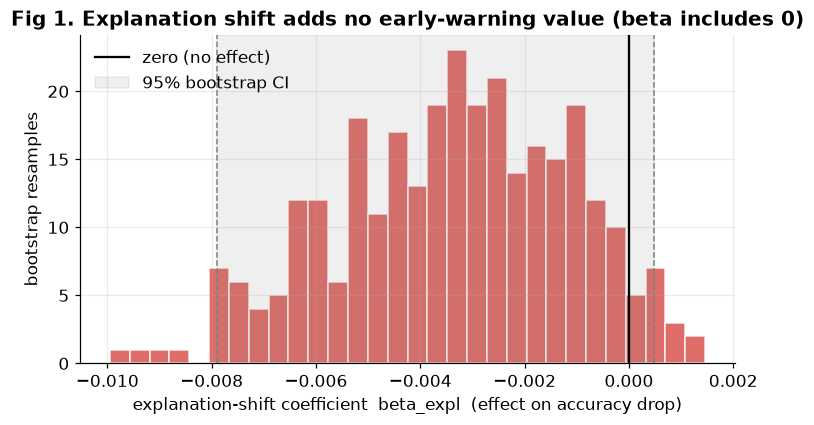

In [4]:
boot = res["boot"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(boot, bins=30, color="#d9534f", alpha=0.85, edgecolor="white")
ax.axvline(0, color="black", lw=1.5, label="zero (no effect)")
ax.axvline(lo, color="grey", ls="--", lw=1); ax.axvline(hi, color="grey", ls="--", lw=1)
ax.axvspan(lo, hi, color="grey", alpha=0.12, label="95% bootstrap CI")
ax.set_xlabel("explanation-shift coefficient  beta_expl  (effect on accuracy drop)")
ax.set_ylabel("bootstrap resamples")
ax.set_title("Fig 1. Explanation shift adds no early-warning value (beta includes 0)")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


## 3. The pooled effect is a Simpson's-paradox artifact

Naively pooling all rows, `Spearman(expl, acc_drop) = -0.27` — which *looks* like explanation
shift points the wrong way. That is misleading: it is driven by between-task differences, not a
within-task relationship. **Within each task**, the picture is small and inconsistent, not
systematically negative.

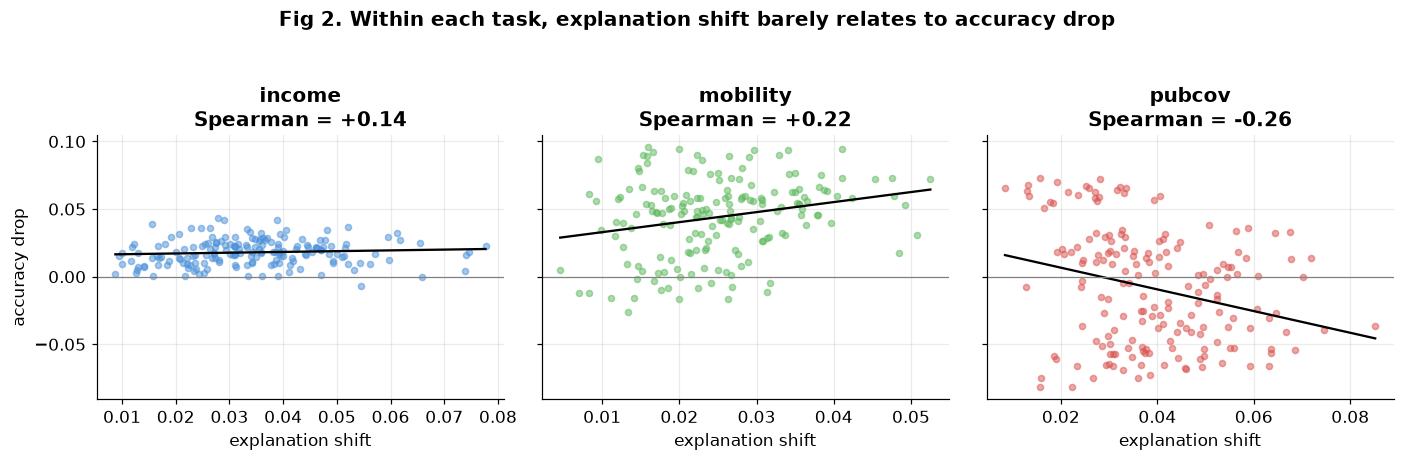

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, (task, g) in zip(axes, df.groupby("task")):
    ax.scatter(g["expl"], g["acc_drop"], s=16, alpha=0.5, color=TASK_COLORS[task])
    b, a = np.polyfit(g["expl"], g["acc_drop"], 1)              # simple trend line
    xs = np.linspace(g["expl"].min(), g["expl"].max(), 50)
    ax.plot(xs, a + b * xs, color="black", lw=1.5)
    ax.axhline(0, color="grey", lw=0.8)
    rho = spearmanr(g["expl"], g["acc_drop"]).statistic
    ax.set_title(f"{task}\nSpearman = {rho:+.2f}")
    ax.set_xlabel("explanation shift")
axes[0].set_ylabel("accuracy drop")
fig.suptitle("Fig 2. Within each task, explanation shift barely relates to accuracy drop",
             y=1.04, fontweight="bold")
plt.tight_layout(); plt.show()


In [6]:
# Controlling for the baselines, within each task: is there ANY incremental value?
rows = []
for task, g in df.groupby("task"):
    g = g.copy()
    for c in ["cov", "pred", "expl"]:
        g[c + "_z"] = (g[c] - g[c].mean()) / g[c].std()
    r = incremental_test(g, "acc_drop", n_boot=120, rng=np.random.default_rng(3), verbose=False)
    rows.append({"task": task, "beta_expl": round(r["beta"], 4),
                 "LRT p": round(r["p_lrt"], 3),
                 "95% CI": f"[{r['ci'][0]:+.4f}, {r['ci'][1]:+.4f}]"})
print("Per-task incremental value of explanation shift (controlling for both baselines):")
pd.DataFrame(rows)


Per-task incremental value of explanation shift (controlling for both baselines):


,task,beta_expl,LRT p,95% CI
0,income,0.0003,0.541,"[-0.0010, +0.0013]"
1,mobility,0.0009,0.194,"[-0.0004, +0.0021]"
2,pubcov,0.0014,0.284,"[-0.0025, +0.0044]"


Every per-task confidence interval straddles zero — **no task shows reliable incremental
value**. The scary pooled −0.27 was an aggregation illusion. The honest conclusion is a clean
**null**, not "explanation shift is harmful".

## 4. Robustness — same test on AUC-drop and PR-AUC-drop

The accuracy-drop result is the pre-registered primary. As robustness, we repeat the incremental
test with ROC-AUC-drop and PR-AUC-drop as outcomes. The conclusion holds: explanation shift never
clears the pre-registered bar.

In [7]:
rob = []
for outc, label in [("acc_drop", "accuracy drop (primary)"),
                    ("auc_drop", "ROC-AUC drop"),
                    ("ap_drop",  "PR-AUC drop")]:
    r = incremental_test(df, outc, n_boot=150, rng=np.random.default_rng(5), verbose=False)
    rob.append({"outcome": label, "beta_expl": round(r["beta"], 4),
                "one-sided p(beta>0)": round(r["p_one"], 3),
                "LRT p": round(r["p_lrt"], 3),
                "95% CI": f"[{r['ci'][0]:+.4f}, {r['ci'][1]:+.4f}]"})
pd.DataFrame(rob)


,outcome,beta_expl,one-sided p(beta>0),LRT p,95% CI
0,accuracy drop (primary),-0.0036,0.991,0.019,"[-0.0086, +0.0008]"
1,ROC-AUC drop,-0.0024,0.999,0.002,"[-0.0046, -0.0004]"
2,PR-AUC drop,-0.0030,0.946,0.109,"[-0.0058, +0.0001]"


## 5. Which label-free signal is the best monitor?

Comparing all three signals against all three outcomes (rank correlation, pooled). The expensive
SHAP-based `explanation_shift` is not the winner; the **cheapest** signal, `prediction_shift`, is
the most consistently right-signed.

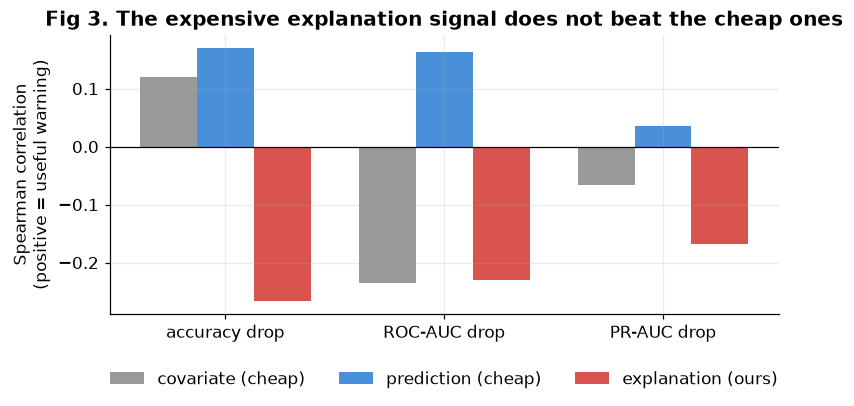

In [8]:
outcomes = ["acc_drop", "auc_drop", "ap_drop"]
sigs = {"cov": "covariate (cheap)", "pred": "prediction (cheap)", "expl": "explanation (ours)"}
M = np.array([[spearmanr(df[s], df[o]).statistic for o in outcomes] for s in sigs])

fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(outcomes)); w = 0.26
colors = ["#999999", "#4a90d9", "#d9534f"]
for i, (key, name) in enumerate(sigs.items()):
    ax.bar(x + (i - 1) * w, M[i], w, label=name, color=colors[i])
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(["accuracy drop", "ROC-AUC drop", "PR-AUC drop"])
ax.set_ylabel("Spearman correlation\n(positive = useful warning)")
ax.set_title("Fig 3. The expensive explanation signal does not beat the cheap ones")
ax.legend(frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.32))
plt.tight_layout(); plt.show()


## 6. Caveats & conclusion

**Caveats (carried into the paper's limitations):**
- Accuracy/AUC drops are modest here (US-census tasks are fairly stable geographically), so the
  predictive ceiling is low for *every* signal — the claim is "no *incremental* value," not "drift
  is unpredictable."
- The `mobility` task is near-chance (in-distribution AUC ≈ 0.57); its accuracy is partly
  base-rate-driven.
- This tests the **global** explanation-shift metric (total-variation distance of mean-|SHAP|
  vectors, fixed background). A *local* per-instance variant was pre-registered as secondary
  "only if the global signal is promising" — it is not, so it is left to future work.

**Conclusion.** Under temporal and geographic shift on open census tasks, a label-free
explanation-shift signal does **not** provide early warning of accuracy loss beyond cheaper drift
baselines — a pre-registered, honestly-reported **NO-GO**. The contribution becomes the
shift-aware trade-off map plus this falsifiable null, with a clear practitioner takeaway: prefer
the cheap `prediction_shift` monitor over an expensive SHAP-based one for this purpose.

---
Pre-registration: [`../../PREREGISTRATION.md`](../../PREREGISTRATION.md) ·
Full write-up: [`../WEEK2_FINDINGS.md`](../WEEK2_FINDINGS.md) ·
Pipeline: [`../../week2_powered.py`](../../week2_powered.py) ·
Data: [`../week2_rows_full.csv`](../week2_rows_full.csv)
